In [ ]:
import tensorflow as tf
import os

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install -q kaggle
!pip install -q seaborn

In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "masoudnickparvar/brain-tumor-mri-dataset"
)

print("Dataset downloaded successfully!")
print(dataset_path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset downloaded successfully!
/kaggle/input/brain-tumor-mri-dataset


In [ ]:
import os

print(os.listdir(dataset_path))

['Training', 'Testing']


In [ ]:
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        continue

brain-tumor-mri-dataset/
    Training/
        pituitary/
        notumor/
        meningioma/
        glioma/
    Testing/
        pituitary/
        notumor/
        meningioma/
        glioma/


In [ ]:
import os

print(os.listdir(dataset_path))

['Training', 'Testing']


In [ ]:
train_path = os.path.join(dataset_path, "Training")
test_path = os.path.join(dataset_path, "Testing")

print("TRAINING CLASSES:")
print(os.listdir(train_path))

print("\nTESTING CLASSES:")
print(os.listdir(test_path))

TRAINING CLASSES:
['pituitary', 'notumor', 'meningioma', 'glioma']

TESTING CLASSES:
['pituitary', 'notumor', 'meningioma', 'glioma']


In [ ]:
print("🧠 TRAINING DATASET\n")

for cls in sorted(os.listdir(train_path)):
    class_path = os.path.join(train_path, cls)

    if os.path.isdir(class_path):
        print(f"{cls}: {len(os.listdir(class_path))} images")


print("\n🧪 TESTING DATASET\n")

for cls in sorted(os.listdir(test_path)):
    class_path = os.path.join(test_path, cls)

    if os.path.isdir(class_path):
        print(f"{cls}: {len(os.listdir(class_path))} images")

🧠 TRAINING DATASET

glioma: 1400 images
meningioma: 1400 images
notumor: 1400 images
pituitary: 1400 images

🧪 TESTING DATASET

glioma: 400 images
meningioma: 400 images
notumor: 400 images
pituitary: 400 images


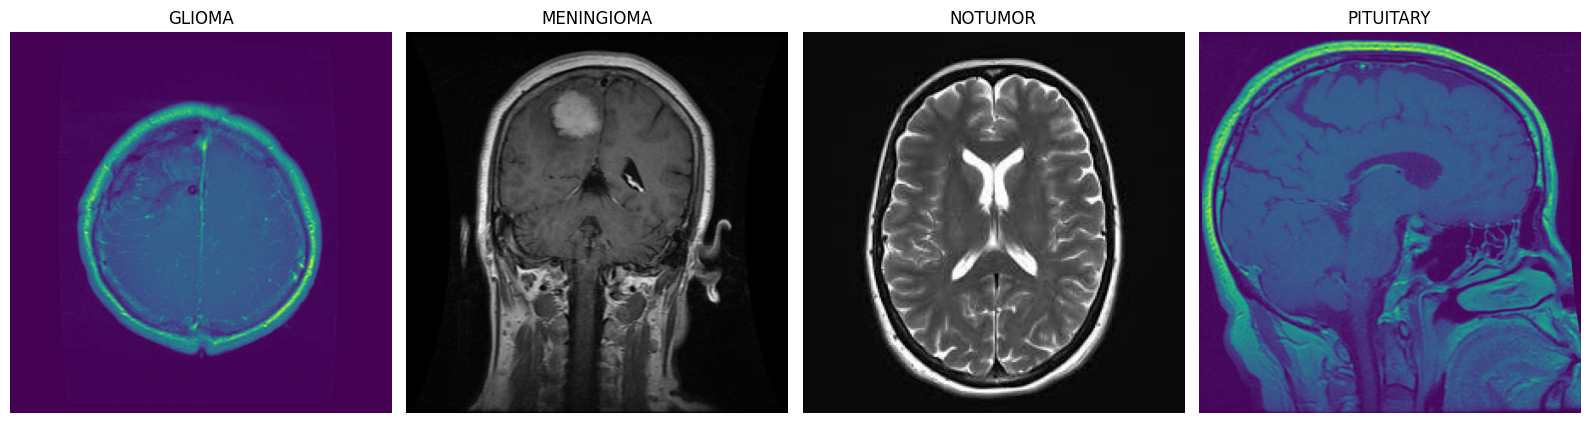

In [ ]:
import matplotlib.pyplot as plt
import random
import os
from PIL import Image

classes = sorted([
    cls for cls in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, cls))
])

plt.figure(figsize=(16, 8))

for i, cls in enumerate(classes):
    class_path = os.path.join(train_path, cls)

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    img_name = random.choice(images)
    img_path = os.path.join(class_path, img_name)

    image = Image.open(img_path)

    plt.subplot(1, 4, i + 1)
    plt.imshow(image)
    plt.title(cls.upper())
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names

print("\n✅ Class Names:")
print(class_names)


Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.

✅ Class Names:
['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="categorical"
)

print("\n✅ Test dataset loaded!")

Found 1600 files belonging to 4 classes.

✅ Test dataset loaded!


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("⚡ Dataset optimized successfully!")


⚡ Dataset optimized successfully!


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

In [ ]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    # Data Augmentation
    data_augmentation,

    # Normalize pixel values
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 4
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Classification
    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(4, activation="softmax")
])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,156 (1.74 MB)

 Trainable params: 456,196 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Custom CNN compiled successfully!")

✅ Custom CNN compiled successfully!


In [ ]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_custom_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )
]

In [ ]:
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 46s 137ms/step - accuracy: 0.6696 - loss: 0.8301 - val_accuracy: 0.2545 - val_loss: 2.6167 - learning_rate: 0.0010
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 129ms/step - accuracy: 0.7431 - loss: 0.6629 - val_accuracy: 0.3964 - val_loss: 5.2346 - learning_rate: 0.0010
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - accuracy: 0.7761 - loss: 0.5866 - val_accuracy: 0.4089 - val_loss: 3.1062 - learning_rate: 0.0010
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 26s 141ms/step - accuracy: 0.8230 - loss: 0.4711 - val_accuracy: 0.4027 - val_loss: 2.7783 - learning_rate: 5.0000e-04
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 133ms/step - accuracy: 0.8384 - loss: 0.4379 - val_accuracy: 0.7795 - val_loss: 0.5829 - learning_rate: 5.0000e-04
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 41s 133ms/step - accuracy: 0.8487 - loss: 0.4054 - val_accuracy: 0.6786 - val_loss: 1.2635 - learning_rate: 5.0000e-04
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 26s 135ms/step - a

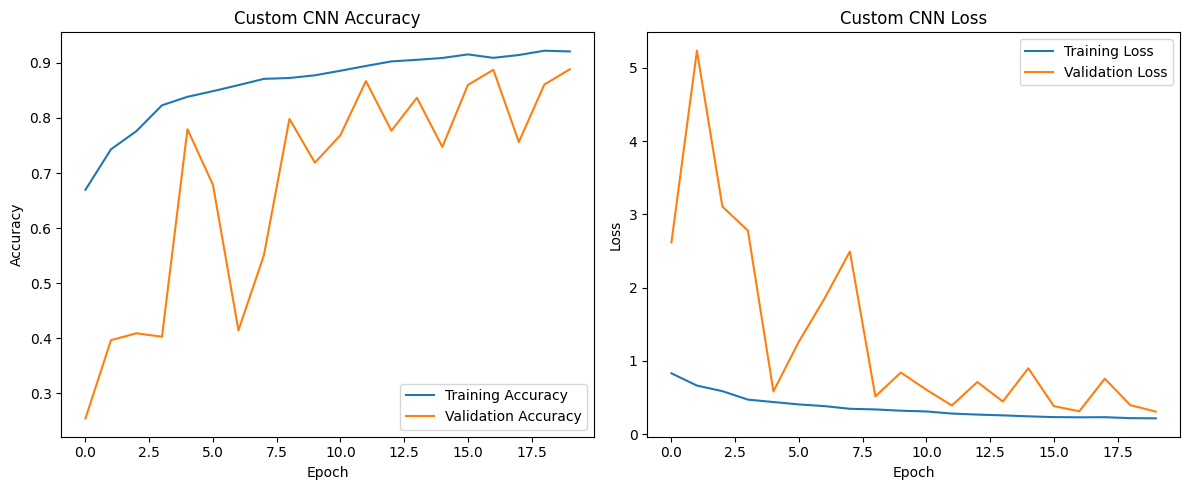

In [ ]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history["accuracy"], label="Training Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation Accuracy")
plt.title("Custom CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history["loss"], label="Training Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")
plt.title("Custom CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_accuracy = cnn_model.evaluate(test_ds)

print("🧠 CUSTOM CNN TEST RESULTS")
print("=" * 40)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.8238 - loss: 0.6917
🧠 CUSTOM CNN TEST RESULTS
Test Loss: 0.6917
Test Accuracy: 82.38%


In [ ]:
import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("✅ Required libraries imported!")

✅ Required libraries imported!


In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = cnn_model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("CLASSIFICATION REPORT\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

CLASSIFICATION REPORT

              precision    recall  f1-score   support

      glioma       0.92      0.72      0.81       400
  meningioma       0.86      0.57      0.69       400
     notumor       0.81      1.00      0.90       400
   pituitary       0.76      1.00      0.86       400

    accuracy                           0.82      1600
   macro avg       0.84      0.82      0.81      1600
weighted avg       0.84      0.82      0.81      1600



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

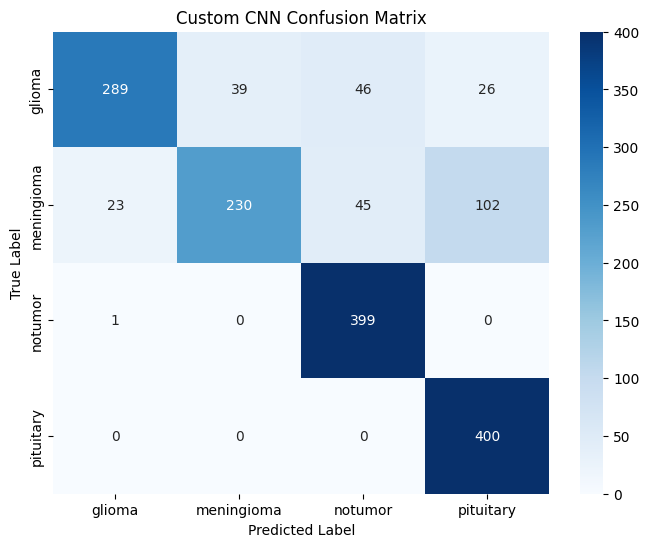

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Custom CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
cnn_model.save("brain_tumor_custom_cnn.keras")

print("✅ Custom CNN model saved successfully!")

✅ Custom CNN model saved successfully!


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.models import Model

In [ ]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers initially
base_model.trainable = False

print("✅ VGG16 loaded successfully!")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ VGG16 loaded successfully!


In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))

# Data augmentation
x = data_augmentation(inputs)

# VGG16 preprocessing
x = preprocess_input(x)

# Pretrained VGG16
x = base_model(x, training=False)

# Classification layers
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

outputs = Dense(
    len(class_names),
    activation="softmax"
)(x)

vgg_model = Model(inputs, outputs)

vgg_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[1][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[1][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[1][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │      1,028 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))

# Data augmentation
x = data_augmentation(inputs)

# VGG16 preprocessing
x = preprocess_input(x)

# Pretrained VGG16
x = base_model(x, training=False)

# Classification layers
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

outputs = Dense(
    len(class_names),
    activation="softmax"
)(x)

vgg_model = Model(inputs, outputs)

vgg_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ sequential[2][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ sequential[2][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ sequential[2][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[1][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 4)         │      1,028 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ VGG16 compiled successfully!")

✅ VGG16 compiled successfully!


In [ ]:
vgg_callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_vgg16.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )
]

In [ ]:
history_vgg = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=vgg_callbacks
)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 41s 210ms/step - accuracy: 0.4487 - loss: 2.4678 - val_accuracy: 0.7580 - val_loss: 0.6644 - learning_rate: 1.0000e-04
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 203ms/step - accuracy: 0.6616 - loss: 1.0837 - val_accuracy: 0.8045 - val_loss: 0.5176 - learning_rate: 1.0000e-04
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 199ms/step - accuracy: 0.7208 - loss: 0.8391 - val_accuracy: 0.8384 - val_loss: 0.4739 - learning_rate: 1.0000e-04
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 211ms/step - accuracy: 0.7522 - loss: 0.6669 - val_accuracy: 0.8500 - val_loss: 0.4238 - learning_rate: 1.0000e-04
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 198ms/step - accuracy: 0.7855 - loss: 0.5883 - val_accuracy: 0.8625 - val_loss: 0.3920 - learning_rate: 1.0000e-04
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 203ms/step - accuracy: 0.7960 - loss: 0.5494 - val_accuracy: 0.8545 - val_loss: 0.4021 - learning_rate: 1.0000e-04
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 20

In [ ]:
# Unfreeze the base model
base_model.trainable = True

# Freeze most layers, train only the last few
for layer in base_model.layers[:-4]:
    layer.trainable = False

print("Total VGG16 layers:", len(base_model.layers))

for layer in base_model.layers:
    print(layer.name, "-", layer.trainable)

Total VGG16 layers: 19
input_layer_2 - False
block1_conv1 - False
block1_conv2 - False
block1_pool - False
block2_conv1 - False
block2_conv2 - False
block2_pool - False
block3_conv1 - False
block3_conv2 - False
block3_conv3 - False
block3_pool - False
block4_conv1 - False
block4_conv2 - False
block4_conv3 - False
block4_pool - False
block5_conv1 - True
block5_conv2 - True
block5_conv3 - True
block5_pool - True


In [ ]:
vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ VGG16 fine-tuning model compiled!")

✅ VGG16 fine-tuning model compiled!


In [ ]:
history_fine = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=vgg_callbacks
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 235ms/step - accuracy: 0.8690 - loss: 0.3443 - val_accuracy: 0.9045 - val_loss: 0.2444 - learning_rate: 1.0000e-05
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 231ms/step - accuracy: 0.9000 - loss: 0.2728 - val_accuracy: 0.9223 - val_loss: 0.2111 - learning_rate: 1.0000e-05
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 230ms/step - accuracy: 0.9067 - loss: 0.2547 - val_accuracy: 0.9393 - val_loss: 0.1693 - learning_rate: 1.0000e-05
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 230ms/step - accuracy: 0.9275 - loss: 0.2033 - val_accuracy: 0.9393 - val_loss: 0.1596 - learning_rate: 1.0000e-05
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 222ms/step - accuracy: 0.9321 - loss: 0.1816 - val_accuracy: 0.9384 - val_loss: 0.1837 - learning_rate: 1.0000e-05
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 232ms/step - accuracy: 0.9415 - loss: 0.1543 - val_accuracy: 0.9330 - val_loss: 0.1822 - learning_rate: 1.0000e-05
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 22

In [ ]:
test_loss_vgg, test_accuracy_vgg = vgg_model.evaluate(test_ds)

print("\n🧠 VGG16 TEST RESULTS")
print("=" * 40)
print(f"Test Loss: {test_loss_vgg:.4f}")
print(f"Test Accuracy: {test_accuracy_vgg * 100:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 153ms/step - accuracy: 0.9231 - loss: 0.4314

🧠 VGG16 TEST RESULTS
Test Loss: 0.4314
Test Accuracy: 92.31%


In [ ]:
y_true_vgg = []
y_pred_vgg = []

for images, labels in test_ds:

    predictions = vgg_model.predict(images, verbose=0)

    y_true_vgg.extend(
        np.argmax(labels.numpy(), axis=1)
    )

    y_pred_vgg.extend(
        np.argmax(predictions, axis=1)
    )

y_true_vgg = np.array(y_true_vgg)
y_pred_vgg = np.array(y_pred_vgg)

print(
    classification_report(
        y_true_vgg,
        y_pred_vgg,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      glioma       0.98      0.80      0.88       400
  meningioma       0.89      0.91      0.90       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.92      0.99      0.96       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.93      0.92      0.92      1600



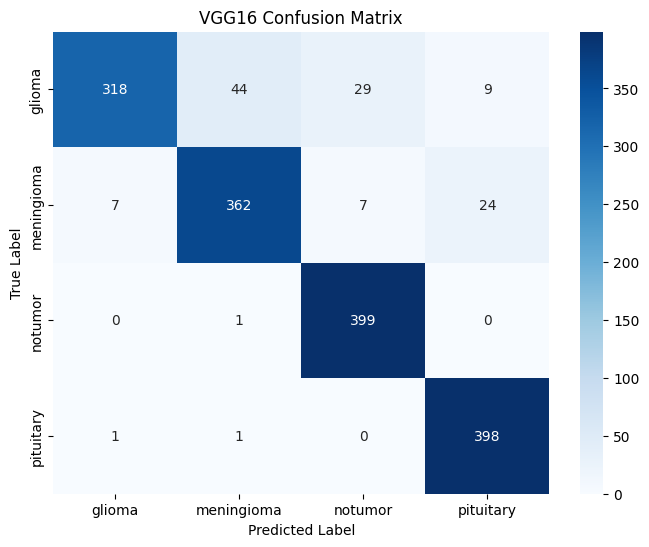

In [ ]:
cm_vgg = confusion_matrix(
    y_true_vgg,
    y_pred_vgg
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_vgg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
vgg_model.save("brain_tumor_vgg16.keras")

print("✅ Final VGG16 model saved!")

✅ Final VGG16 model saved!


In [ ]:
# Print convolution layers

for layer in vgg_model.layers:
    print(layer.name, type(layer).__name__)

input_layer_4 InputLayer
sequential Sequential
vgg16 Functional
global_average_pooling2d_2 GlobalAveragePooling2D
dense_4 Dense
dropout_2 Dropout
dense_5 Dense


In [ ]:
last_conv_layer_name = "block5_conv3"

print("Last convolution layer:", last_conv_layer_name)

Last convolution layer: block5_conv3


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
# Get the last convolution layer

last_conv_layer = base_model.get_layer("block5_conv3")

print("✅ Grad-CAM layer found:")
print(last_conv_layer.name)

✅ Grad-CAM layer found:
block5_conv3


In [ ]:
import cv2
from tensorflow.keras.preprocessing import image


# Choose an image

sample_class = class_names[0]

sample_folder = os.path.join(
    test_path,
    sample_class
)

sample_image_name = os.listdir(sample_folder)[0]

sample_image_path = os.path.join(
    sample_folder,
    sample_image_name
)


# Load image

img = image.load_img(
    sample_image_path,
    target_size=(224, 224)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)


# Get prediction

prediction = vgg_model.predict(img_array)

predicted_class = np.argmax(prediction[0])

confidence = np.max(prediction[0]) * 100


print("🧠 AI PREDICTION")

print(
    "Predicted Class:",
    class_names[predicted_class]
)

print(
    f"Confidence: {confidence:.2f}%"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step
🧠 AI PREDICTION
Predicted Class: glioma
Confidence: 78.00%


In [ ]:
def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name):

    # Model from VGG16 input to last convolution layer
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            base_model.output
        ]
    )

    with tf.GradientTape() as tape:

        # Pass image through the full model
        predictions = model(img_array)

        pred_index = tf.argmax(predictions[0])

        # Get intermediate VGG16 output
        x = model.layers[1](img_array) if False else img_array

        # We need gradients through the base model
        processed_img = preprocess_input(img_array)

        conv_output, _ = grad_model(processed_img)

        # Get prediction through classifier layers
        x = GlobalAveragePooling2D()(conv_output)

In [ ]:
def make_gradcam_heatmap(img_array):

    # Create a model that maps input image to:
    # 1. Last convolution layer
    # 2. Final predictions

    grad_model = tf.keras.models.Model(
        inputs=vgg_model.inputs,
        outputs=[
            base_model.get_layer("block5_conv3").output,
            vgg_model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_output, predictions = grad_model(img_array)

        predicted_class = tf.argmax(predictions[0])

        loss = predictions[:, predicted_class]

    # Calculate gradients
    grads = tape.gradient(loss, conv_output)

    # Average gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_output = conv_output[0]

    # Multiply feature maps by importance
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    # ReLU
    heatmap = tf.maximum(heatmap, 0)

    # Normalize
    heatmap /= tf.reduce_max(heatmap) + tf.keras.backend.epsilon()

    return heatmap.numpy()

In [ ]:
for i, layer in enumerate(vgg_model.layers):
    print(i, layer.name, type(layer).__name__)

0 input_layer_4 InputLayer
1 sequential Sequential
2 vgg16 Functional
3 global_average_pooling2d_2 GlobalAveragePooling2D
4 dense_4 Dense
5 dropout_2 Dropout
6 dense_5 Dense


In [ ]:
# Get the nested VGG16 model from our main model
vgg_base = None

for layer in vgg_model.layers:
    if isinstance(layer, tf.keras.Model):
        vgg_base = layer
        print("Found nested model:", layer.name)

# Get the last convolutional layer
last_conv_layer = vgg_base.get_layer("block5_conv3")

print("Last Conv Layer:", last_conv_layer.name)

Found nested model: sequential
Found nested model: vgg16
Last Conv Layer: block5_conv3


In [ ]:
def make_gradcam_heatmap(img_array):

    # Convert to TensorFlow tensor
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:

        # Forward pass through the COMPLETE model
        predictions = vgg_model(img_tensor, training=False)

        # Predicted class
        pred_index = tf.argmax(predictions[0])

        # Score for predicted class
        class_score = predictions[:, pred_index]

        # Create a separate feature model
        feature_model = tf.keras.Model(
            inputs=vgg_base.input,
            outputs=last_conv_layer.output
        )

        # Apply preprocessing exactly as training
        x = data_augmentation(img_tensor, training=False)
        x = preprocess_input(x)

        # Get convolution features
        conv_output = feature_model(x, training=False)

    # Gradient of prediction score w.r.t convolution output
    grads = tape.gradient(class_score, conv_output)

    print("Gradient shape:", grads)

    return conv_output, grads

In [ ]:
vgg_base = vgg_model.get_layer("vgg16")

print("✅ VGG16 model found!")
print(vgg_base.name)

✅ VGG16 model found!
vgg16


In [ ]:
for layer in vgg_base.layers[-10:]:
    print(layer.name, type(layer).__name__)

block3_conv3 Conv2D
block3_pool MaxPooling2D
block4_conv1 Conv2D
block4_conv2 Conv2D
block4_conv3 Conv2D
block4_pool MaxPooling2D
block5_conv1 Conv2D
block5_conv2 Conv2D
block5_conv3 Conv2D
block5_pool MaxPooling2D


In [ ]:
last_conv_layer = vgg_base.get_layer("block5_conv3")

print("✅ Last convolution layer found:")
print(last_conv_layer.name)

✅ Last convolution layer found:
block5_conv3


In [ ]:
grad_model = tf.keras.models.Model(
    inputs=vgg_base.input,
    outputs=[
        vgg_base.get_layer("block5_conv3").output,
        vgg_base.output
    ]
)

print("✅ Grad-CAM feature model created!")

✅ Grad-CAM feature model created!


In [ ]:
def make_gradcam_heatmap(img_array):

    img_tensor = tf.cast(img_array, tf.float32)

    # Get prediction first
    predictions = vgg_model(img_tensor, training=False)

    pred_index = tf.argmax(predictions[0])

    with tf.GradientTape() as tape:

        # Apply preprocessing exactly like the model
        x = data_augmentation(
            img_tensor,
            training=False
        )

        x = preprocess_input(x)

        # Get convolution output
        conv_output, vgg_output = grad_model(
            x,
            training=False
        )

        # Watch convolution output
        tape.watch(conv_output)

        # Recreate classification head
        x = vgg_output

        # Pass through layers AFTER VGG16
        start_processing = False

        for layer in vgg_model.layers:

            if layer.name == "vgg16":
                start_processing = True
                continue

            if start_processing:

                if isinstance(
                    layer,
                    tf.keras.layers.GlobalAveragePooling2D
                ):
                    x = layer(x)

                elif isinstance(
                    layer,
                    tf.keras.layers.Dense
                ):
                    x = layer(x)

                elif isinstance(
                    layer,
                    tf.keras.layers.Dropout
                ):
                    x = layer(x, training=False)

        predictions = x

        class_score = predictions[:, pred_index]

    # Calculate gradients
    grads = tape.gradient(
        class_score,
        conv_output
    )

    # Average gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_output = conv_output[0]

    # Multiply feature maps with importance weights
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    # ReLU
    heatmap = tf.maximum(heatmap, 0)

    # Normalize
    heatmap = heatmap / (
        tf.reduce_max(heatmap)
        + tf.keras.backend.epsilon()
    )

    return heatmap.numpy()

In [ ]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("✅ Class names saved!")
print(class_names)

✅ Class names saved!
['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
cnn_metrics = {
    "model": "Custom CNN",
    "test_accuracy": float(test_accuracy * 100)
}

vgg_metrics = {
    "model": "VGG16",
    "test_accuracy": float(test_accuracy_vgg * 100)
}

metrics = {
    "custom_cnn": cnn_metrics,
    "vgg16": vgg_metrics
}

with open("model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("✅ Metrics saved!")
print(metrics)

✅ Metrics saved!
{'custom_cnn': {'model': 'Custom CNN', 'test_accuracy': 82.37500190734863}, 'vgg16': {'model': 'VGG16', 'test_accuracy': 92.31250286102295}}


In [ ]:
vgg_precision = precision_score(
    y_true_vgg,
    y_pred_vgg,
    average="weighted"
)

vgg_recall = recall_score(
    y_true_vgg,
    y_pred_vgg,
    average="weighted"
)

vgg_f1 = f1_score(
    y_true_vgg,
    y_pred_vgg,
    average="weighted"
)

print("🧠 VGG16 FINAL METRICS")
print("=" * 40)

print(f"Accuracy : {test_accuracy_vgg * 100:.2f}%")
print(f"Precision: {vgg_precision * 100:.2f}%")
print(f"Recall   : {vgg_recall * 100:.2f}%")
print(f"F1 Score : {vgg_f1 * 100:.2f}%")

🧠 VGG16 FINAL METRICS
Accuracy : 92.31%
Precision: 92.58%
Recall   : 92.31%
F1 Score : 92.14%


In [ ]:
metrics = {
    "custom_cnn": {
        "accuracy": float(test_accuracy * 100)
    },

    "vgg16": {
        "accuracy": float(test_accuracy_vgg * 100),
        "precision": float(vgg_precision * 100),
        "recall": float(vgg_recall * 100),
        "f1_score": float(vgg_f1 * 100)
    }
}

with open("model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("✅ Complete metrics saved!")

✅ Complete metrics saved!


In [ ]:
from google.colab import files

files.download("brain_tumor_vgg16.keras")
files.download("class_names.json")
files.download("model_metrics.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

print("Current files:")
print(os.listdir())

Current files:
['.config', 'class_names.json', 'model_metrics.json', 'brain_tumor_vgg16.keras', 'best_vgg16.keras', 'brain_tumor_custom_cnn.keras', 'best_custom_cnn.keras', 'sample_data']


In [61]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
import numpy as np
import json
import os
import plotly.graph_objects as go
from PIL import Image


# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="NeuroVision AI",
    page_icon="🧠",
    layout="wide",
    initial_sidebar_state="expanded"
)


# ============================================================
# PREMIUM BLACK UI
# ============================================================

st.markdown("""
<style>

/* MAIN APP */

.stApp {
    background-color: #050505;
    color: #FFFFFF;
}


/* REMOVE STREAMLIT ELEMENTS */

#MainMenu {
    visibility: hidden;
}

footer {
    visibility: hidden;
}

header {
    visibility: hidden;
}


/* SIDEBAR */

section[data-testid="stSidebar"] {
    background-color: #090909;
    border-right: 1px solid #222222;
}


/* TEXT */

h1 {
    color: #00E5FF;
}

h2 {
    color: #FFFFFF;
}

h3 {
    color: #00E5FF;
}


/* HERO SECTION */

.hero {

    padding: 60px 30px;

    border-radius: 25px;

    text-align: center;

    background:

    radial-gradient(
        circle at center,
        #102a35 0%,
        #081216 35%,
        #050505 75%
    );

    border: 1px solid #1d3b45;

    box-shadow:
    0px 0px 40px rgba(0,229,255,0.10);

    margin-bottom: 30px;
}


/* NORMAL CARD */

.card {

    background:

    linear-gradient(
        145deg,
        #111111,
        #080808
    );

    border: 1px solid #242424;

    border-radius: 18px;

    padding: 25px;

    margin-bottom: 20px;

    box-shadow:

    0px 0px 20px
    rgba(0,229,255,0.05);
}


/* FEATURE CARD */

.feature-card {

    background:

    linear-gradient(
        145deg,
        #101010,
        #070707
    );

    border: 1px solid #222222;

    border-radius: 18px;

    padding: 25px;

    text-align: center;

    min-height: 200px;

    transition: 0.3s;

}


.feature-card:hover {

    border: 1px solid #00E5FF;

    box-shadow:

    0px 0px 25px
    rgba(0,229,255,0.15);

}


/* METRIC CARD */

.metric-card {

    background-color: #101010;

    border: 1px solid #222222;

    border-radius: 15px;

    padding: 20px;

    text-align: center;

}


/* BUTTON */

.stButton > button {

    width: 100%;

    background:

    linear-gradient(
        90deg,
        #008CFF,
        #00C6FF
    );

    color: white;

    border: none;

    border-radius: 10px;

    padding: 12px;

    font-size: 16px;

    font-weight: 600;

}


.stButton > button:hover {

    box-shadow:

    0px 0px 25px
    rgba(0,229,255,0.5);

}


/* FILE UPLOADER */

[data-testid="stFileUploader"] {

    background-color: #101010;

    border-radius: 15px;

    padding: 15px;

    border: 1px solid #222222;

}


/* RADIO BUTTON */

.stRadio label {

    color: white;

}


/* ALERTS */

.stAlert {

    border-radius: 12px;

}


/* DIVIDER */

hr {

    border-color: #222222;

}


/* IMAGE */

img {

    border-radius: 12px;

}

</style>
""", unsafe_allow_html=True)


# ============================================================
# FILE PATHS
# ============================================================

MODEL_PATH = "brain_tumor_vgg16.keras"
CLASS_PATH = "class_names.json"
METRICS_PATH = "model_metrics.json"


# ============================================================
# LOAD MODEL
# ============================================================

@st.cache_resource
def load_ai_model():

    model = tf.keras.models.load_model(
        MODEL_PATH,
        compile=False
    )

    return model


# ============================================================
# LOAD DATA
# ============================================================

@st.cache_data
def load_project_data():

    with open(CLASS_PATH, "r") as f:
        class_names = json.load(f)

    metrics = {}

    if os.path.exists(METRICS_PATH):

        with open(METRICS_PATH, "r") as f:
            metrics = json.load(f)

    return class_names, metrics


# ============================================================
# CHECK FILES
# ============================================================

missing_files = []

if not os.path.exists(MODEL_PATH):
    missing_files.append(MODEL_PATH)

if not os.path.exists(CLASS_PATH):
    missing_files.append(CLASS_PATH)


if missing_files:

    st.error("❌ Required files are missing!")

    for file in missing_files:
        st.write("Missing:", file)

    st.stop()


# ============================================================
# LOAD MODEL
# ============================================================

try:

    model = load_ai_model()

    class_names, metrics = load_project_data()

except Exception as e:

    st.error("❌ Error while loading NeuroVision AI")

    st.code(str(e))

    st.stop()


# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_mri(image):

    image = image.convert("RGB")

    image_resized = image.resize(
        (224, 224)
    )

    img_array = np.array(
        image_resized,
        dtype=np.float32
    )

    img_array = np.expand_dims(
        img_array,
        axis=0
    )


    prediction = model.predict(
        img_array,
        verbose=0
    )[0]


    predicted_index = int(
        np.argmax(prediction)
    )


    predicted_class = class_names[
        predicted_index
    ]


    confidence = float(
        prediction[predicted_index] * 100
    )


    return (
        predicted_class,
        confidence,
        prediction
    )


# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.markdown("""

<div style="
text-align:center;
padding:20px;
">

<h1 style="
color:#00E5FF;
font-size:32px;
">

🧠

<br>

NeuroVision AI

</h1>

<p style="
color:#888;
font-size:14px;
">

AI-Powered Brain MRI Analysis

</p>

</div>

""", unsafe_allow_html=True)


page = st.sidebar.radio(

    "Navigation",

    [

        "🏠 Home",

        "🔬 MRI Analysis",

        "🧠 Brain Tumor Guide",

        "📊 Model Performance",

        "🤖 How AI Works",

        "ℹ️ About"

    ]
)


st.sidebar.markdown("---")

st.sidebar.caption(
    "Deep Learning • Computer Vision • AI"
)


# ============================================================
# HOME PAGE
# ============================================================

if page == "🏠 Home":

    st.markdown("""

    <div class="hero">

    <h1 style="
    font-size:60px;
    color:#00E5FF;
    ">

    🧠 NEUROVISION AI

    </h1>


    <h2>

    Intelligent Brain MRI Analysis

    </h2>


    <p style="
    color:#AAAAAA;
    font-size:20px;
    ">

    Deep Learning • VGG16 •
    Computer Vision • Explainable AI

    </p>

    </div>

    """, unsafe_allow_html=True)


    col1, col2, col3 = st.columns(3)


    with col1:

        st.markdown("""

        <div class="feature-card">

        <h1>🔬</h1>

        <h3>MRI Analysis</h3>

        <p style="color:#AAAAAA">

        Upload a brain MRI image
        and receive an AI-powered
        classification.

        </p>

        </div>

        """, unsafe_allow_html=True)


    with col2:

        st.markdown("""

        <div class="feature-card">

        <h1>🤖</h1>

        <h3>Deep Learning</h3>

        <p style="color:#AAAAAA">

        Powered by convolutional
        neural networks and
        VGG16 transfer learning.

        </p>

        </div>

        """, unsafe_allow_html=True)


    with col3:

        st.markdown("""

        <div class="feature-card">

        <h1>📊</h1>

        <h3>AI Confidence</h3>

        <p style="color:#AAAAAA">

        Explore probability scores
        for every predicted
        MRI classification.

        </p>

        </div>

        """, unsafe_allow_html=True)


    st.markdown("---")


    st.markdown("""

    <div class="card">

    <h2>🚀 Welcome to NeuroVision AI</h2>

    <p style="color:#BBBBBB;font-size:17px">

    NeuroVision AI is an educational deep learning
    application designed to demonstrate how
    Convolutional Neural Networks can analyze
    brain MRI images.

    </p>


    <br>


    <h3>AI Classification Categories</h3>

    🔴 <b>Glioma</b>

    <br><br>

    🟠 <b>Meningioma</b>

    <br><br>

    🟢 <b>No Tumor</b>

    <br><br>

    🟣 <b>Pituitary Tumor</b>


    </div>

    """, unsafe_allow_html=True)


    st.warning("""

⚠️ NeuroVision AI is an educational and research project.

It is NOT a medical diagnosis system and must not
replace evaluation by a qualified healthcare professional.

""")


# ============================================================
# MRI ANALYSIS PAGE
# ============================================================

elif page == "🔬 MRI Analysis":

    st.title("🔬 AI Brain MRI Analysis")

    st.write("""

Upload a brain MRI image and allow NeuroVision AI
to perform deep learning-based classification.

""")


    uploaded_file = st.file_uploader(

        "Upload Brain MRI Image",

        type=[
            "jpg",
            "jpeg",
            "png"
        ]

    )


    if uploaded_file is not None:


        try:

            uploaded_image = Image.open(
                uploaded_file
            ).convert("RGB")


            col1, col2 = st.columns(2)


            with col1:

                st.subheader(
                    "🖼️ Uploaded MRI"
                )

                st.image(
                    uploaded_image,
                    use_container_width=True
                )


            with col2:

                st.markdown("""

                <div class="card">

                <h2>🤖 Ready for Analysis</h2>

                <p style="color:#AAAAAA">

                NeuroVision AI will:

                <br><br>

                1️⃣ Preprocess the MRI image

                <br><br>

                2️⃣ Extract visual features

                <br><br>

                3️⃣ Apply VGG16 deep learning

                <br><br>

                4️⃣ Generate class probabilities

                </p>

                </div>

                """, unsafe_allow_html=True)


            st.write("")


            analyze_button = st.button(
                "🧠 ANALYZE MRI"
            )


            if analyze_button:


                with st.spinner(

                    "🧠 NeuroVision AI is analyzing the MRI..."

                ):


                    predicted_class, confidence, prediction = predict_mri(
                        uploaded_image
                    )


                st.markdown("---")


                st.success(
                    "✅ AI Analysis Completed"
                )


                col1, col2 = st.columns(2)


                with col1:

                    st.markdown("""

                    <div class="card">

                    <h3>🤖 AI Prediction</h3>

                    """, unsafe_allow_html=True)


                    st.markdown(

                        f"""

                        <h1 style="
                        color:#00E5FF;
                        font-size:40px;
                        ">

                        {predicted_class.upper()}

                        </h1>

                        """,

                        unsafe_allow_html=True
                    )


                    st.markdown("""

                    </div>

                    """, unsafe_allow_html=True)


                with col2:

                    st.markdown("""

                    <div class="card">

                    <h3>🎯 Confidence</h3>

                    """, unsafe_allow_html=True)


                    st.markdown(

                        f"""

                        <h1 style="
                        color:#00E5FF;
                        font-size:40px;
                        ">

                        {confidence:.2f}%

                        </h1>

                        """,

                        unsafe_allow_html=True
                    )


                    st.progress(
                        min(
                            int(confidence),
                            100
                        )
                    )


                    st.markdown("""

                    </div>

                    """, unsafe_allow_html=True)


                # ====================================================
                # PROBABILITY CHART
                # ====================================================


                st.markdown("---")

                st.subheader(
                    "📊 AI Classification Probabilities"
                )


                probabilities = prediction * 100


                fig = go.Figure()


                fig.add_trace(

                    go.Bar(

                        x=class_names,

                        y=probabilities,

                        text=[
                            f"{x:.2f}%"
                            for x in probabilities
                        ],

                        textposition="outside"

                    )

                )


                fig.update_layout(

                    title="Prediction Confidence Distribution",

                    paper_bgcolor="#050505",

                    plot_bgcolor="#050505",

                    font=dict(
                        color="white"
                    ),

                    xaxis=dict(
                        title="Classification"
                    ),

                    yaxis=dict(
                        title="Confidence (%)",
                        range=[0, 100]
                    ),

                    height=500

                )


                st.plotly_chart(

                    fig,

                    use_container_width=True

                )


                # ====================================================
                # CLASS INFORMATION
                # ====================================================


                st.markdown("---")

                st.subheader(
                    "🧠 Classification Information"
                )


                info = {

                    "glioma": """

Gliomas are tumors associated with glial cells.
Their characteristics and clinical significance
can vary depending on the specific type and grade.

""",

                    "meningioma": """

Meningiomas arise from the meninges, which are
protective layers surrounding the brain and spinal cord.

""",

                    "pituitary": """

Pituitary tumors involve the pituitary region.
The pituitary gland plays an important role
in hormone regulation.

""",

                    "notumor": """

This dataset category represents images labelled
as having no tumor.

An AI result should never replace professional
medical evaluation.

"""

                }


                predicted_lower = predicted_class.lower().replace(
                    " ",
                    ""
                )


                displayed_info = None


                for key in info:

                    if key in predicted_lower:

                        displayed_info = info[key]


                if displayed_info:

                    st.markdown(

                        f"""

                        <div class="card">

                        {displayed_info}

                        </div>

                        """,

                        unsafe_allow_html=True

                    )


                st.warning("""

⚠️ IMPORTANT MEDICAL DISCLAIMER

This prediction is generated by an experimental
machine learning model.

It should NOT be used for medical diagnosis,
treatment decisions, or emergency situations.

Please consult a qualified medical professional.

""")


        except Exception as e:

            st.error(
                "❌ Error while processing the image."
            )

            st.code(str(e))


    else:

        st.info(
            "👆 Upload an MRI image to begin analysis."
        )


# ============================================================
# BRAIN TUMOR GUIDE
# ============================================================

elif page == "🧠 Brain Tumor Guide":


    st.title("🧠 Brain Tumor Guide")


    st.write("""

Explore general educational information about
the categories used by the AI model.

""")


    tumor = st.selectbox(

        "Select a Classification Category",

        [

            "Glioma",

            "Meningioma",

            "Pituitary Tumor",

            "No Tumor"

        ]

    )


    if tumor == "Glioma":


        st.markdown("""

        <div class="card">

        <h2>🔴 Glioma</h2>

        <p style="color:#BBBBBB">

        Gliomas are tumors associated with glial
        cells, which support and protect neurons.

        </p>


        <h3>General Information</h3>

        • Associated with glial cells

        <br><br>

        • Can occur in different areas of the brain

        <br><br>

        • Different gliomas can behave differently

        <br><br>

        • Clinical evaluation is required for diagnosis

        </div>

        """, unsafe_allow_html=True)


    elif tumor == "Meningioma":


        st.markdown("""

        <div class="card">

        <h2>🟠 Meningioma</h2>

        <p style="color:#BBBBBB">

        Meningiomas arise from the meninges,
        protective membranes surrounding the
        brain and spinal cord.

        </p>


        <h3>General Information</h3>

        • Associated with the meninges

        <br><br>

        • Can occur in different locations

        <br><br>

        • Characteristics vary between cases

        <br><br>

        • Medical imaging and clinical evaluation
        are required for diagnosis

        </div>

        """, unsafe_allow_html=True)


    elif tumor == "Pituitary Tumor":


        st.markdown("""

        <div class="card">

        <h2>🟣 Pituitary Tumor</h2>

        <p style="color:#BBBBBB">

        Pituitary tumors involve the pituitary
        region.

        </p>


        <h3>General Information</h3>

        • Located near the pituitary gland

        <br><br>

        • The pituitary gland is involved
        in hormone regulation

        <br><br>

        • Clinical characteristics vary

        <br><br>

        • Professional evaluation is necessary

        </div>

        """, unsafe_allow_html=True)


    else:


        st.markdown("""

        <div class="card">

        <h2>🟢 No Tumor</h2>

        <p style="color:#BBBBBB">

        This class represents MRI images labelled
        as having no tumor within the dataset.

        </p>

        <br>

        An AI classification result alone cannot
        guarantee the absence of disease.

        </div>

        """, unsafe_allow_html=True)


    st.warning("""

⚠️ Educational information only.
For medical advice, consult a qualified healthcare professional.

""")


# ============================================================
# MODEL PERFORMANCE
# ============================================================

elif page == "📊 Model Performance":


    st.title("📊 Deep Learning Model Performance")


    st.write("""

Performance metrics obtained during the
experimental evaluation of the models.

""")


    vgg_data = metrics.get(
        "vgg16",
        {}
    )


    cnn_data = metrics.get(
        "custom_cnn",
        {}
    )


    # SUPPORT DIFFERENT METRIC FILE VERSIONS

    vgg_accuracy = vgg_data.get(

        "accuracy",

        vgg_data.get(
            "test_accuracy",
            0
        )

    )


    cnn_accuracy = cnn_data.get(

        "accuracy",

        cnn_data.get(
            "test_accuracy",
            0
        )

    )


    precision = vgg_data.get(
        "precision",
        0
    )

    recall = vgg_data.get(
        "recall",
        0
    )

    f1_score = vgg_data.get(
        "f1_score",
        0
    )


    col1, col2, col3, col4 = st.columns(4)


    with col1:

        st.metric(

            "🎯 Accuracy",

            f"{vgg_accuracy:.2f}%"

        )


    with col2:

        st.metric(

            "📌 Precision",

            f"{precision:.2f}%"

        )


    with col3:

        st.metric(

            "🔍 Recall",

            f"{recall:.2f}%"

        )


    with col4:

        st.metric(

            "⚡ F1 Score",

            f"{f1_score:.2f}%"

        )


    st.markdown("---")


    st.subheader(
        "🏆 Model Comparison"
    )


    fig = go.Figure()


    fig.add_trace(

        go.Bar(

            x=[
                "Custom CNN",
                "VGG16"
            ],

            y=[
                cnn_accuracy,
                vgg_accuracy
            ],

            text=[

                f"{cnn_accuracy:.2f}%",

                f"{vgg_accuracy:.2f}%"

            ],

            textposition="outside"

        )

    )


    fig.update_layout(

        title="Accuracy Comparison",

        paper_bgcolor="#050505",

        plot_bgcolor="#050505",

        font=dict(
            color="white"
        ),

        yaxis=dict(
            range=[0, 100],
            title="Accuracy (%)"
        )

    )


    st.plotly_chart(

        fig,

        use_container_width=True

    )


# ============================================================
# HOW AI WORKS
# ============================================================

elif page == "🤖 How AI Works":


    st.title(
        "🤖 How NeuroVision AI Works"
    )


    st.markdown("""

    <div class="card">

    <h2>🧠 Deep Learning Pipeline</h2>

    <br>

    <h3>

    🖼️ MRI IMAGE

    <br><br>

    ⬇️

    <br><br>

    IMAGE PREPROCESSING

    <br><br>

    ⬇️

    <br><br>

    RESIZE TO 224 × 224

    <br><br>

    ⬇️

    <br><br>

    🧠 VGG16 FEATURE EXTRACTION

    <br><br>

    ⬇️

    <br><br>

    DEEP LEARNING CLASSIFIER

    <br><br>

    ⬇️

    <br><br>

    📊 SOFTMAX PROBABILITIES

    <br><br>

    ⬇️

    <br><br>

    🤖 AI PREDICTION

    </h3>

    </div>

    """, unsafe_allow_html=True)


    st.markdown("""

    <div class="card">

    <h2>🔬 What is VGG16?</h2>

    <p style="color:#BBBBBB">

    VGG16 is a convolutional neural network
    architecture widely used for image recognition.

    In this project, transfer learning is used
    to leverage features learned from a large
    image dataset and adapt them for brain MRI
    image classification.

    </p>

    </div>

    """, unsafe_allow_html=True)


# ============================================================
# ABOUT
# ============================================================

elif page == "ℹ️ About":


    st.title(
        "ℹ️ About NeuroVision AI"
    )


    st.markdown("""

    <div class="card">

    <h1>🧠 NeuroVision AI</h1>


    <p style="
    color:#BBBBBB;
    font-size:17px;
    ">

    NeuroVision AI is a deep learning project
    demonstrating the application of
    Convolutional Neural Networks and
    Transfer Learning for brain MRI
    image classification.

    </p>


    <br>


    <h2>⚙️ Technology Stack</h2>


    🐍 Python

    <br><br>

    🤖 TensorFlow & Keras

    <br><br>

    🧠 VGG16 Transfer Learning

    <br><br>

    🌐 Streamlit

    <br><br>

    📊 Plotly

    <br><br>

    🔬 Deep Learning


    </div>

    """, unsafe_allow_html=True)


    st.markdown("---")


    st.warning("""

⚠️ DISCLAIMER

NeuroVision AI is developed for educational,
academic, and research purposes.

It is NOT a certified medical device and
must not be used as a substitute for
professional medical diagnosis.

""")

Writing app.py


In [62]:
!pip install -q streamlit plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 58.7 MB/s eta 0:00:00


In [64]:
!nohup streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > streamlit.log 2>&1 &

In [65]:
!cat streamlit.log



2026-09-06 07:57:58.020 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.161.121:8501



In [66]:
!curl -I http://127.0.0.1:8501

HTTP/1.1 200 OK
date: Sun, 06 Sep 2026 07:58:20 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 7459
last-modified: Sun, 06 Sep 2026 07:57:01 GMT
etag: "0b37b92d39b78df448b84b7bd4684fdf"
cache-control: no-cache



In [67]:
!cat streamlit.log



2026-09-06 07:57:58.020 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.161.121:8501



In [68]:
!pkill -f cloudflared

In [69]:
!nohup cloudflared tunnel --url http://127.0.0.1:8501 > cloudflare.log 2>&1 &

In [71]:
!curl -I http://127.0.0.1:8501

HTTP/1.1 200 OK
date: Sun, 06 Sep 2026 07:59:48 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 7459
last-modified: Sun, 06 Sep 2026 07:57:01 GMT
etag: "0b37b92d39b78df448b84b7bd4684fdf"
cache-control: no-cache



In [73]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb

!dpkg -i cloudflared-linux-amd64.deb

Selecting previously unselected package cloudflared.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.8.3) ...
Setting up cloudflared (2026.8.3) ...
Processing triggers for man-db (2.10.2-1) ...


In [74]:
!cloudflared --version

cloudflared version 2026.8.3 (built 2026-08-31-10:04 UTC)


In [75]:
!nohup cloudflared tunnel --url http://127.0.0.1:8501 > cloudflare.log 2>&1 &

In [76]:
!cat cloudflare.log

2026-09-06T08:00:53Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-06T08:00:53Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-06T08:00:57Z INF +--------------------------------------------------------------------------------------------+
2026-09-06T08:00:57Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-06T08:00:57Z INF |  https://harper-punch-whose-oecd.trycloudflare.com    